Import all the needed Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # to ignore warning message
import plotly.express as px

Read the dataset file 

In [5]:
df=pd.read_csv(r"D:\resume_project\python -projects\Hotels_project\hotels.csv")


Data Exploratory Analysis(EDA)& data cleaning  

In [6]:
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [7]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
""" when we make groupby for 2 col we can do that by make in series like next code"""
""" round here for minimize the zeros & numbers  after the dot 9.00"""
# ee=df.groupby(['country','meal'])['is_canceled'].value_counts().round(2)
# """ unstack the function we use it after we group some col to show like a table  """
# ee2=ee.unstack(level=0)
# ee2
# ee.plot(kind='bar')
# plt.show()
""" when i need just 2 or 3 col from all the dataframe i make like that   new_df=df[['col1','col2','col3']]"""

In [9]:
df.shape

(119390, 36)

In [10]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='object')

change datatype for the (reservation_status_date)col

In [11]:
df['reservation_status_date']=pd.to_datetime(df['reservation_status_date'])
df['reservation_status_date'].info

<bound method Series.info of 0        2015-07-01
1        2015-07-01
2        2015-07-02
3        2015-07-02
4        2015-07-03
            ...    
119385   2017-09-06
119386   2017-09-07
119387   2017-09-07
119388   2017-09-07
119389   2017-09-07
Name: reservation_status_date, Length: 119390, dtype: datetime64[ns]>

In [12]:
#when we pass include='object' inside the describe method we tell him that we need the object describe also from all the static num  
#freq here mean how many this value has repeated
df.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,name,email,phone-number,credit_card
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,81503,115889,119390,9000
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,Michael Johnson,Michael.C@gmail.com,669-792-1661,************4923
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,48,6,1,28


To see the unique values itself inside the object col

In [13]:
for col in df.describe(include='object'):
    print (col)
    print('')
    print(df[col].unique())
    print('-'*100)


hotel

['Resort Hotel' 'City Hotel']
----------------------------------------------------------------------------------------------------
arrival_date_month

['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
----------------------------------------------------------------------------------------------------
meal

['BB' 'FB' 'HB' 'SC' 'Undefined']
----------------------------------------------------------------------------------------------------
country

['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' nan 'ROU' 'NOR' 'OMN' 'ARG' 'POL'
 'DEU' 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST'
 'CZE' 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR'
 'UKR' 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'AGO'
 'ISR' 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM'
 'HRV' 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY'
 'KWT' 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' 

The non-values

In [14]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [15]:
df.drop(['agent','company'],axis=1,inplace=True)
df.dropna(inplace=True)

In [16]:
df.isnull().sum()


hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [17]:
#after we remove the non-value
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898
mean,0.371352,104.311435,2016.157656,27.166555,15.800880,0.928897,2.502145,1.858391,0.104207,0.007948,0.032011,0.087142,0.131634,0.221181,2.330754,102.003243,0.061885,0.571683,2016-07-30 07:37:53.336809984
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483168,106.903309,0.707459,13.589971,8.780324,0.996216,1.900168,0.578576,0.399172,0.097380,0.176029,0.845869,1.484672,0.652785,17.630452,50.485862,0.244172,0.792678,NaN


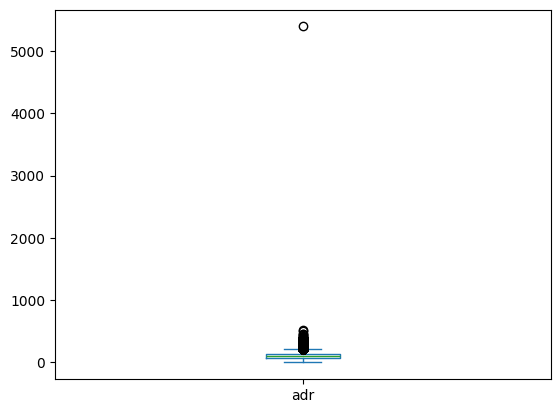

In [18]:
#find out the outliers values 
df['adr'].plot(kind='box')
plt.show()

In [19]:
#deal with the outliers values
df=df[df['adr']<5000]

In [20]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897
mean,0.371347,104.312018,2016.157657,27.166674,15.800802,0.928905,2.502157,1.858390,0.104208,0.007948,0.032011,0.087143,0.131635,0.221175,2.330774,101.958683,0.061885,0.571688,2016-07-30 07:39:51.289939968
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,510.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483167,106.903570,0.707462,13.589966,8.780321,0.996217,1.900171,0.578578,0.399174,0.097381,0.176030,0.845872,1.484678,0.652784,17.630525,48.091199,0.244173,0.792680,NaN


Data Analysis & Visualization 

In [21]:
#make new col for the reservation status
df['new_reservation_status'] = df['is_canceled'].replace({0: 'Booked', 1: 'Canceled'})
df['new_reservation_status'].unique()

array(['Booked', 'Canceled'], dtype=object)

In [22]:
is_canceled=df['new_reservation_status'].value_counts()
is_canceled


new_reservation_status
Booked      74745
Canceled    44152
Name: count, dtype: int64

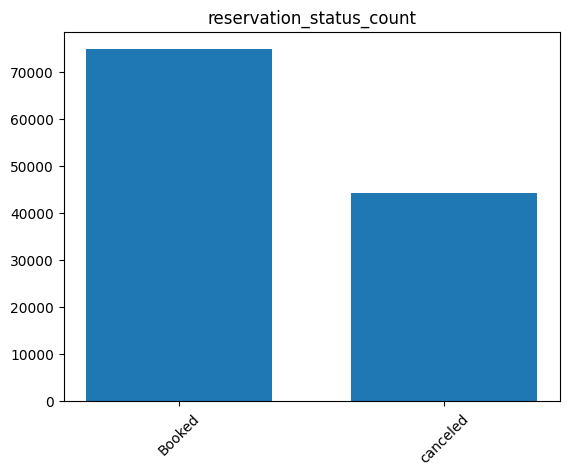

In [23]:
plt.bar(['Booked','canceled'],df['new_reservation_status'].value_counts(),width=0.7)
plt.xticks(rotation=45)
plt.title("reservation_status_count")
plt.show()

In [24]:
# we pass (normalize=True) inside value_counts method to return the values by percentage 
is_canceled_perc=df['new_reservation_status'].value_counts(normalize=True)*100
is_canceled_perc
# 37% is canceled from the reservation
#62% is not canceled from the reservation

new_reservation_status
Booked      62.865337
Canceled    37.134663
Name: proportion, dtype: float64

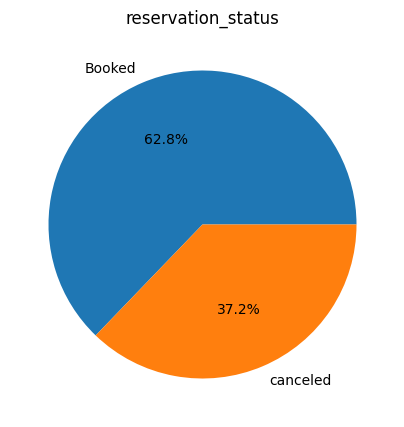

In [25]:
canceled_reservation=37.2
reservation=62.8
list=[reservation,canceled_reservation]
labels_list=['Booked','canceled']
plt.figure(figsize=(5,5))
plt.pie(list,labels=labels_list,autopct="%1.1f%%")
plt.title("reservation_status")
plt.show()

which hotel has the most cancellation values

In [26]:
cancellation_values=df.groupby('hotel')['new_reservation_status'].value_counts()
cancellation_values

hotel         new_reservation_status
City Hotel    Booked                    46226
              Canceled                  33075
Resort Hotel  Booked                    28519
              Canceled                  11077
Name: count, dtype: int64

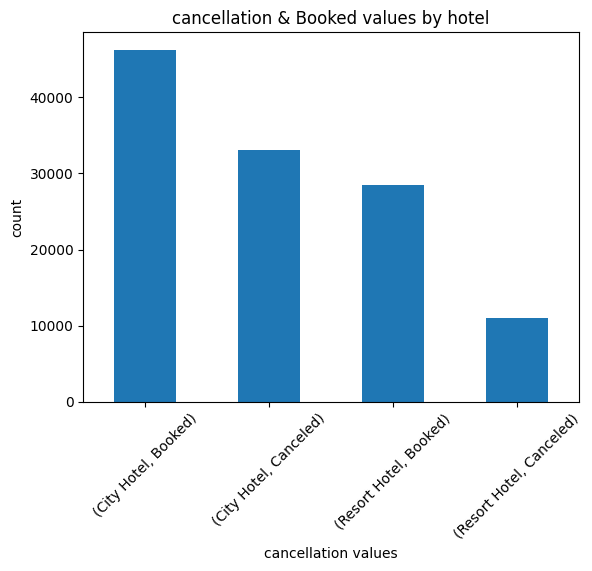

In [27]:
df.groupby('hotel')['new_reservation_status'].value_counts().plot(kind='bar')
plt.title('cancellation & Booked values by hotel')
plt.xlabel('cancellation values')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.show()

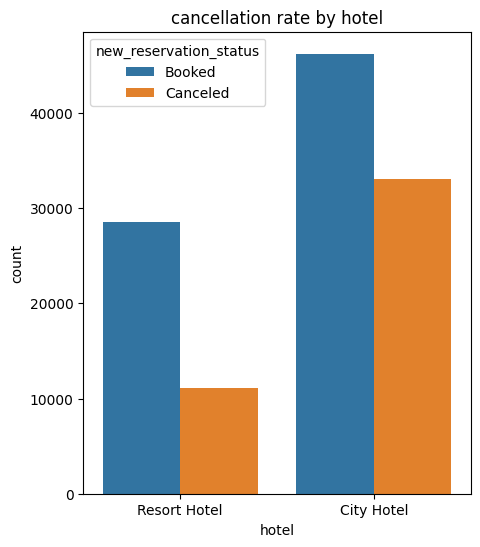

In [28]:

plt.figure(figsize=(5,6))
sns.countplot(x='hotel',hue='new_reservation_status',data=df)
plt.title('cancellation rate by hotel')
plt.show()

compare cancellation rate by hotel  

In [29]:
city_hotel=df[df['hotel']=='City Hotel']   # this line return a dataframe based on condition that  [df['hotel']=='Resort Hotel']
city_hotel['new_reservation_status'].value_counts(normalize=True) # we multiply *100 to make it percentage

new_reservation_status
Booked      0.582918
Canceled    0.417082
Name: proportion, dtype: float64

In [30]:
Resort_hotel=df[df['hotel']=='Resort Hotel']   # this line return a dataframe based on condition that  [df['hotel']=='Resort Hotel']
Resort_hotel['new_reservation_status'].value_counts(normalize=True)

new_reservation_status
Booked      0.72025
Canceled    0.27975
Name: proportion, dtype: float64

why we have hight cancellation rate 

In [31]:
#adr means (ave daily rate)
Resort_hotel=Resort_hotel.groupby('reservation_status_date')[['adr']].mean() # we put [['adr']] like that to return this line as df not Series we use it in drew later
city_hotel
Resort_hotel

,adr
reservation_status_date,
2014-11-18,0.000000
2015-01-01,61.966667
2015-01-02,9.633750
2015-01-18,0.000000
2015-01-21,37.301209
...,...
2017-09-08,101.012500
2017-09-09,147.778333
2017-09-10,145.272500


In [32]:
#adr means (ave daily rate)
city_hotel=city_hotel.groupby('reservation_status_date')[['adr']].mean()  # we put [['adr']] like that to return this line as df not Series we use it in drew later
city_hotel

,adr
reservation_status_date,
2014-10-17,62.800000
2015-01-01,62.063158
2015-01-20,76.500000
2015-01-30,61.400000
2015-02-17,76.500000
...,...
2017-09-03,137.172600
2017-09-04,116.925385
2017-09-05,154.000000


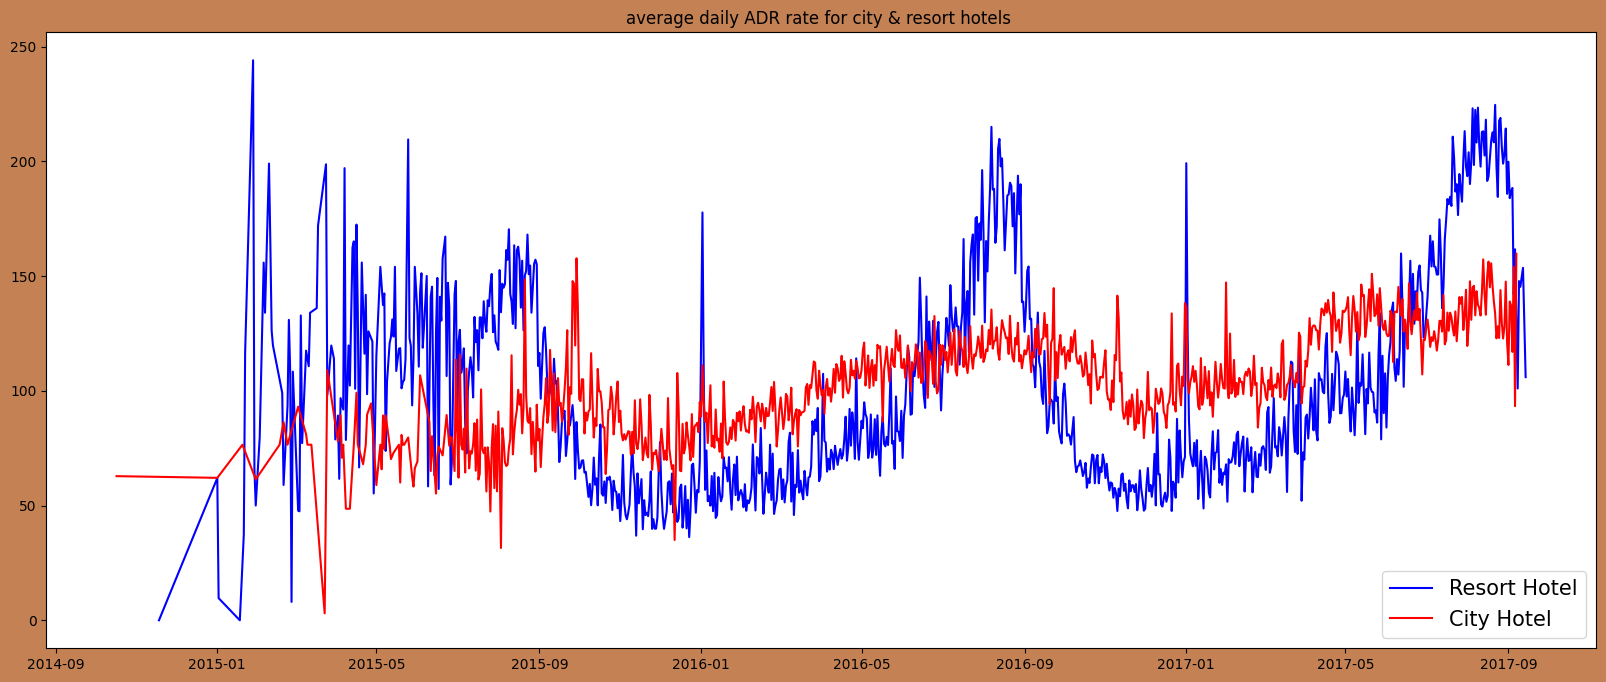

In [33]:
plt.figure(figsize=(20,8),facecolor='#C38154') #facecolor is for make a frame for the image 
plt.title("average daily ADR rate for city & resort hotels ")
plt.plot(Resort_hotel.index,Resort_hotel['adr'],color='blue',label='Resort Hotel')
plt.plot(city_hotel.index,city_hotel['adr'],color='red',label='City Hotel')
plt.legend(fontsize=15)
plt.show()

Max & Min reservation_status by Months

In [34]:
df['month']=df['reservation_status_date'].dt.month


In [35]:
max_rate=df.groupby('month')[['adr']].max()
max_rate

,adr
month,
1,451.50
2,382.00
3,331.33
4,392.00
5,510.00
6,388.00
7,508.00
8,437.00
9,384.00


In [65]:
min_rate=df.groupby('month')[['adr']].min()
min_rate

,adr
month,
1,0.00
2,0.00
3,-6.38
4,0.00
5,0.00
6,0.00
7,0.00
8,0.00
9,0.00


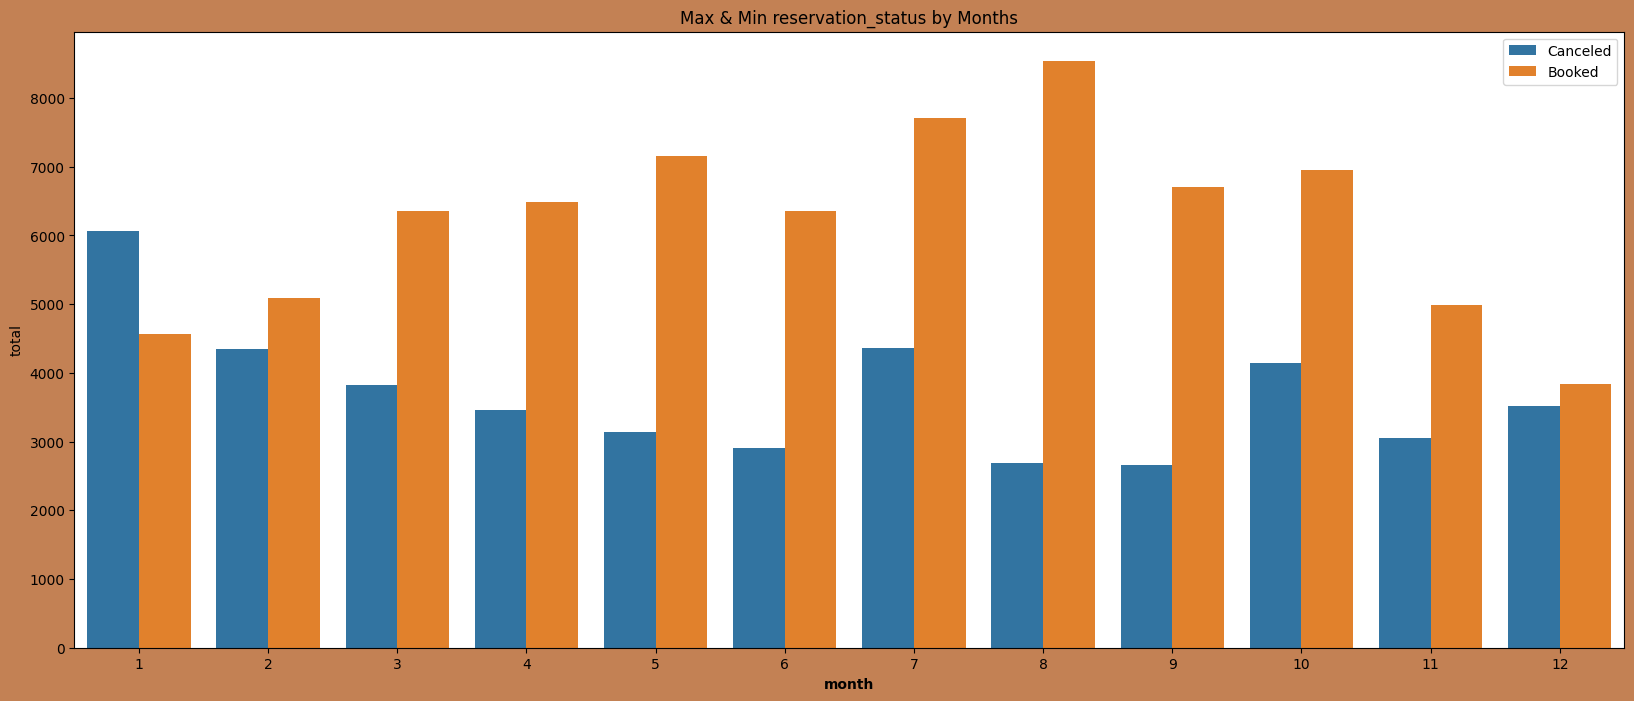

In [37]:
plt.figure(figsize=(20,8),facecolor='#C38154') #facecolor is for make a frame for the image 
plt.title("Max & Min reservation_status by Months")
sns.countplot(x='month',hue='new_reservation_status',data=df)
plt.xlabel('month',fontweight='bold')
plt.ylabel('total')
plt.legend(fontsize=10)
plt.show()

Max & Min reservation_status by Hotel

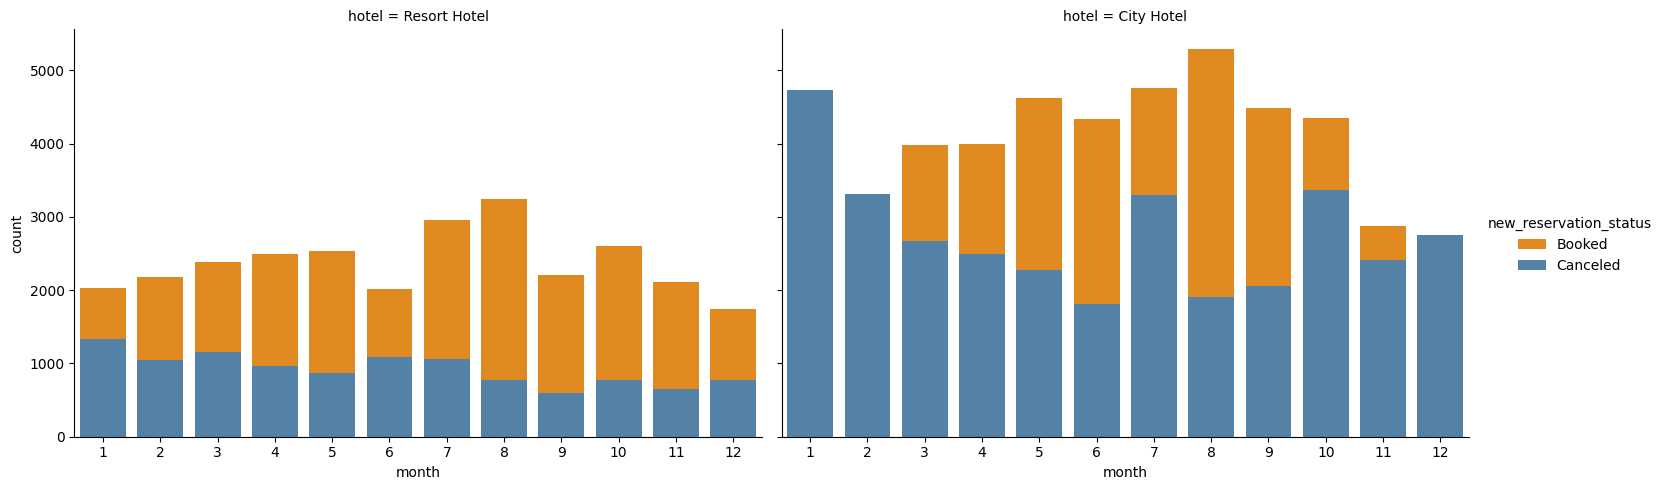

In [38]:
palette_colors = {'Booked': 'darkorange', 'Canceled': 'steelblue'}
g = sns.FacetGrid(df, col="hotel", hue="new_reservation_status", height=5, aspect=1.5, palette=palette_colors)
g.map(sns.countplot, "month", order=sorted(df['month'].unique()), dodge=True)
g.add_legend()
plt.show()


Total ADR per month

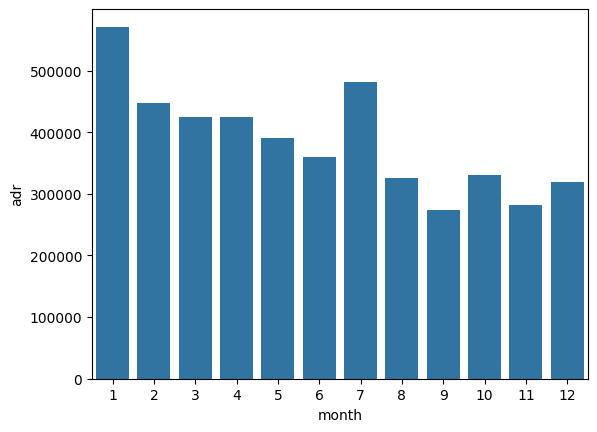

In [39]:
# we use inndex.rest to make it anew reset by the method start from 0 
total_adr=df[df['new_reservation_status']=='Canceled'].groupby('month')['adr'].sum().reset_index()
sns.barplot(x='month',y='adr',data=total_adr)
plt.show()

Top countries of cancel reservation 

In [40]:
top_country=df[df['new_reservation_status']=='Canceled'].groupby('country')['new_reservation_status'].value_counts()[:10]
top_country

country  new_reservation_status
AGO      Canceled                  205
ALB      Canceled                    2
AND      Canceled                    5
ARE      Canceled                   43
ARG      Canceled                   54
ARM      Canceled                    2
AUS      Canceled                  107
AUT      Canceled                  230
AZE      Canceled                    9
BEL      Canceled                  474
Name: count, dtype: int64

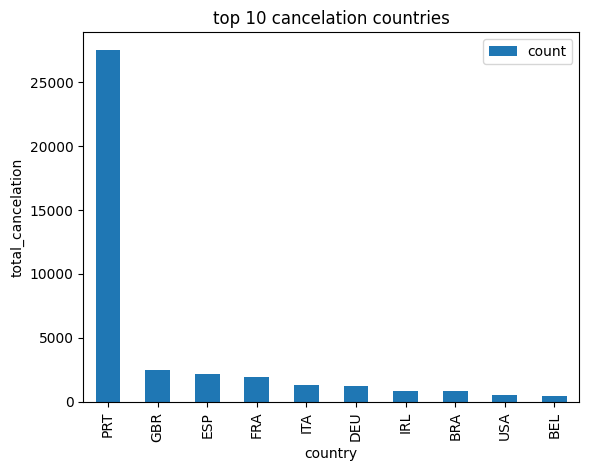

In [41]:
#we make df with condition filter
filter_reservation=df[df['new_reservation_status']=='Canceled']
#[:10] we use for filter top 10
filter_reservation['country'].value_counts()[:10].plot(kind='bar') 
plt.legend()
plt.ylabel('total_cancelation')
plt.title('top 10 cancelation countries') 
plt.show()                                      




Market_segment

In [42]:
df['market_segment'].value_counts(normalize=True)

market_segment
Online TA        0.474377
Offline TA/TO    0.203193
Groups           0.166581
Direct           0.104696
Corporate        0.042987
Complementary    0.006173
Aviation         0.001993
Name: proportion, dtype: float64

In [43]:
filter_reservation['market_segment'].value_counts(normalize=True)

market_segment
Online TA        0.469696
Groups           0.273985
Offline TA/TO    0.187466
Direct           0.043486
Corporate        0.022151
Complementary    0.002038
Aviation         0.001178
Name: proportion, dtype: float64

the ADR with Cancellation & Booked status BY date

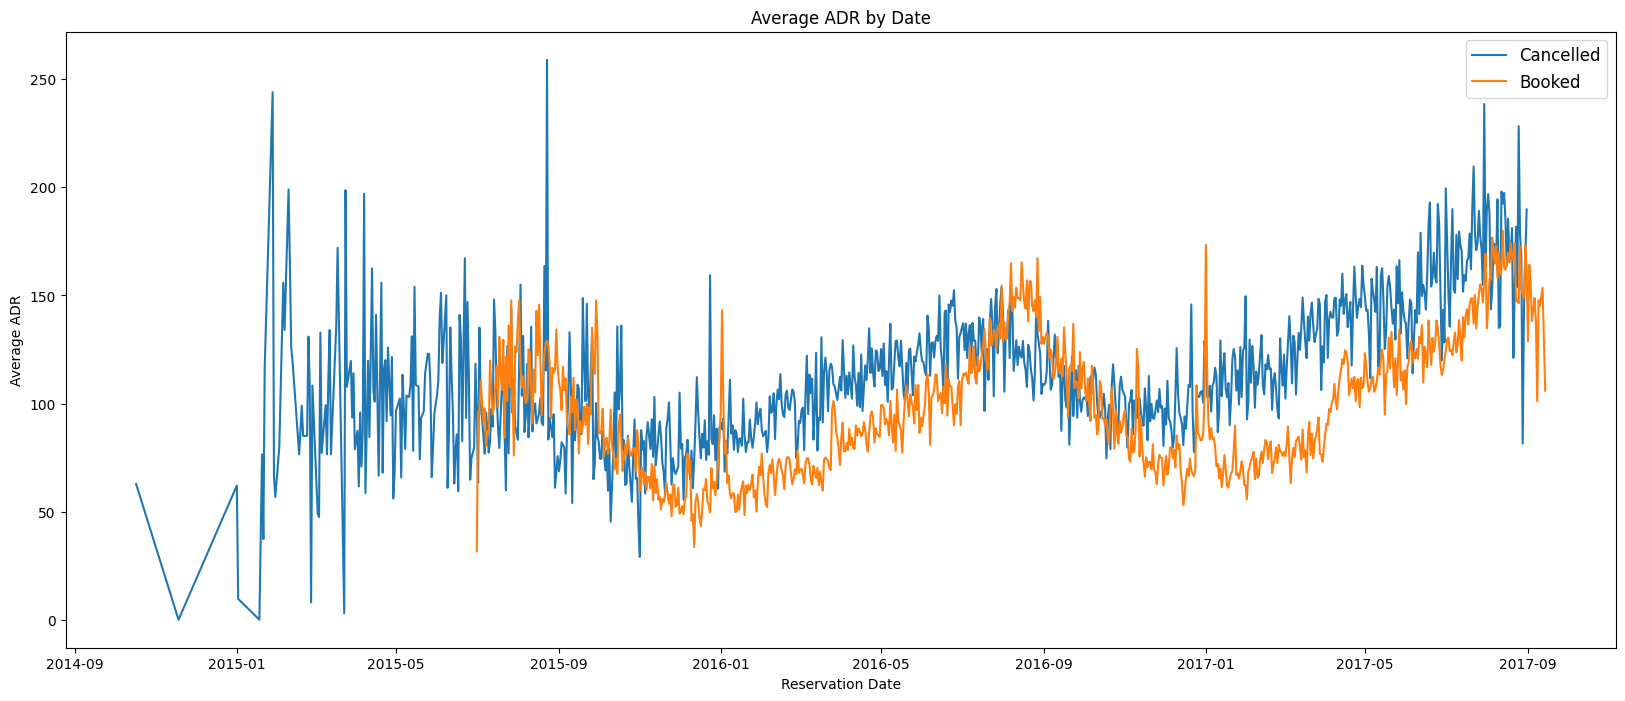

In [44]:
#filter_reservation=df[df['new_reservation_status']=='Canceled']

Cancellation_adr= filter_reservation.groupby('reservation_status_date')[['adr']].mean()
Cancellation_adr.reset_index(inplace=True)
Cancellation_adr.sort_values('reservation_status_date',inplace=True)

filter_reservation_booked=df[df['new_reservation_status']=='Booked']
Booked_adr=filter_reservation_booked.groupby('reservation_status_date')[['adr']].mean()
Booked_adr.reset_index(inplace=True)
Booked_adr.sort_values('reservation_status_date',inplace=True) # by default ascending =true

plt.figure(figsize=(20,8))
plt.plot(Cancellation_adr['reservation_status_date'],Cancellation_adr['adr'],label='Cancelled')
plt.plot(Booked_adr['reservation_status_date'],Booked_adr['adr'],label='Booked')
plt.xlabel('Reservation Date')
plt.ylabel('Average ADR')
plt.title('Average ADR by Date')
plt.legend(fontsize=12)
plt.show()





show it in specific period

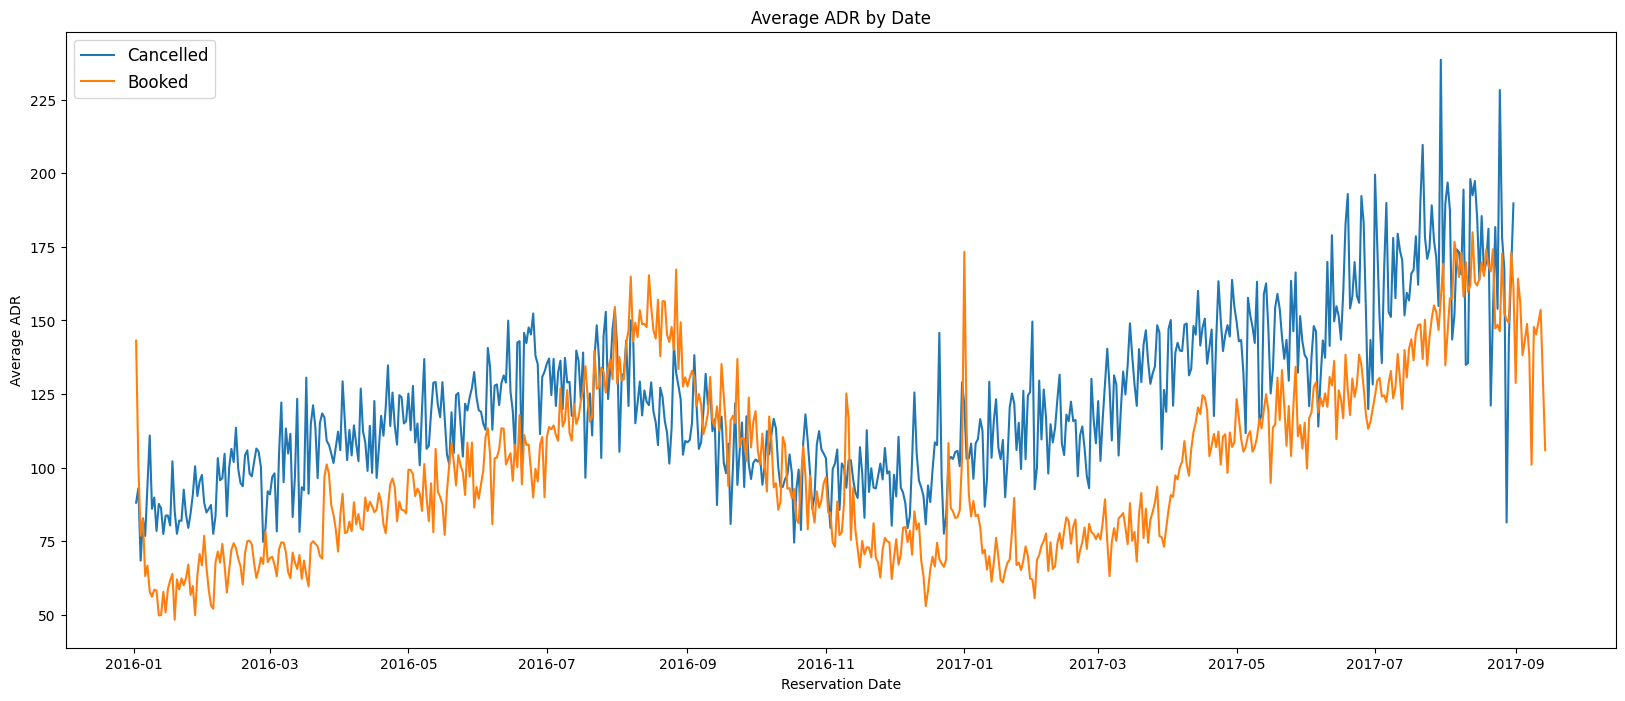

In [45]:
Cancellation_adr=Cancellation_adr[(Cancellation_adr['reservation_status_date']>'2016') & (Cancellation_adr['reservation_status_date']<'2019')]
Booked_adr=Booked_adr[(Booked_adr['reservation_status_date']>'2016') & (Booked_adr['reservation_status_date']<'2019')]
plt.figure(figsize=(20,8))
plt.plot(Cancellation_adr['reservation_status_date'],Cancellation_adr['adr'],label='Cancelled')
plt.plot(Booked_adr['reservation_status_date'],Booked_adr['adr'],label='Booked')
plt.xlabel('Reservation Date')
plt.ylabel('Average ADR')
plt.title('Average ADR by Date')
plt.legend(fontsize=12)
plt.show()


Hight price months in the two hotels 

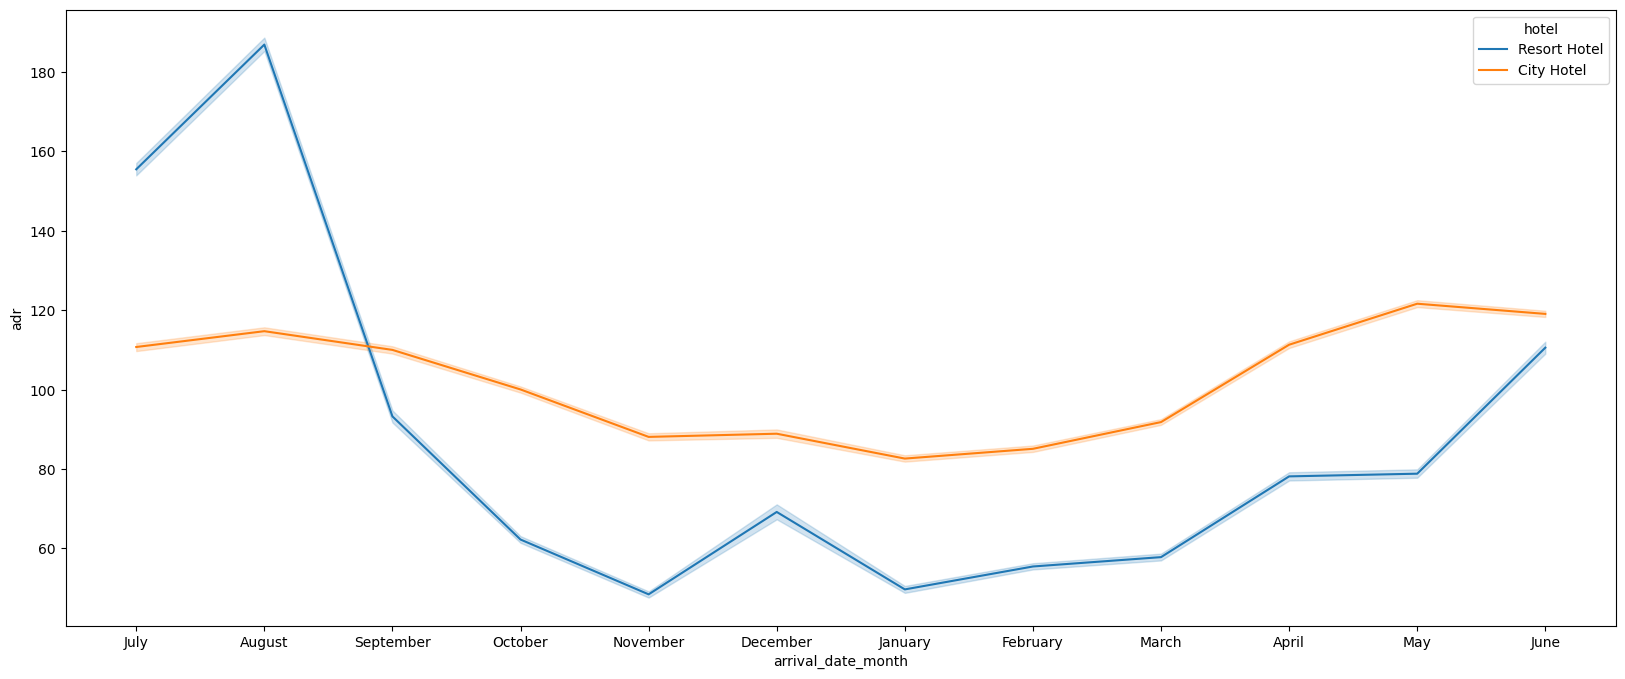

In [46]:
plt.figure(figsize=(20,8))
sns.lineplot(x='arrival_date_month',y='adr',hue='hotel',data=df)
plt.show()

Compare the prices &reservation of rooms in each hotel 

In [47]:
rooms=df[df['is_canceled']==0]
px.box(data_frame=rooms,x='reserved_room_type',y='adr',color='hotel',template='plotly_dark')

#The End